In [17]:
# ==========================================
# 1. INSTALL & IMPORT LIBRARY
# ==========================================
!pip install pmdarima statsmodels scikit-learn matplotlib seaborn pandas numpy tensorflow prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import drive, files

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import tensorflow as tf

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# ==========================================
# 2. MOUNT GOOGLE DRIVE & BACA DATA (PIZZA SALES)
# ==========================================
print("Menghubungkan ke Google Drive...")
drive.mount('/content/drive')

# SESUAIKAN: Ganti path di bawah ini dengan lokasi file Pizza Sales Anda
file_path = '/content/drive/MyDrive/Colab Notebooks/Pizza_sales.csv'

print(f"\nMembaca data dari: {file_path} ...")
try:
    # Menggunakan engine python agar kebal terhadap ParserError
    df = pd.read_csv(file_path, sep=None, engine='python', on_bad_lines='skip')
    print("Berhasil memuat dataset Pizza Sales!\n")
except FileNotFoundError:
    print(f"ERROR: File tidak ditemukan di {file_path}. Pastikan path sudah benar!")
    raise

# DEBUG: Tampilkan kolom yang tersedia
print("Kolom yang tersedia:", df.columns.tolist())
print("5 baris pertama:")
print(df.head())

# Deteksi nama kolom date secara otomatis (case-insensitive)
date_col = None
for col in df.columns:
    if col.lower() in ['date', 'dates', 'tanggal', 'order_date']:
        date_col = col
        break

if date_col is None:
    raise ValueError(f"Kolom tanggal tidak ditemukan. Kolom yang ada: {df.columns.tolist()}")

print(f"\nMenggunakan kolom '{date_col}' sebagai tanggal")

# Deteksi nama kolom quantity/money secara otomatis
quantity_col = None
for col in df.columns:
    if col.lower() in ['quantity', 'qty', 'jumlah', 'amount', 'total', 'money', 'sales', 'penjualan', 'harga']:
        quantity_col = col
        break

if quantity_col is None:
    raise ValueError(f"Kolom quantity/money tidak ditemukan. Kolom yang ada: {df.columns.tolist()}")

print(f"Menggunakan kolom '{quantity_col}' sebagai target prediksi")

# Preprocessing Tanggal & Agregasi Mingguan
df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
df = df.dropna(subset=[date_col])

# Jika quantity_col berbentuk string (e.g., 'R10,00'), bersihkan dulu
if df[quantity_col].dtype == 'object':
    df[quantity_col] = df[quantity_col].astype(str).replace({'R': '', ',': '.'}, regex=True).astype(float)

# Mengelompokkan total quantity/money per hari
df_daily = df.groupby(date_col)[quantity_col].sum().reset_index()
df_daily.set_index(date_col, inplace=True)

# Resample menjadi data Mingguan (W) agar tren lebih stabil
y = df_daily[quantity_col].resample('W').sum()

# Menangani nilai kosong (NaN) setelah resample jika ada minggu tanpa penjualan
y = y.fillna(0)

# Membagi data (80% Train, 20% Test)
train_size = int(len(y) * 0.8)
train, test = y.iloc[:train_size], y.iloc[train_size:]

print(f"\nTotal Data Mingguan: {len(y)} minggu")
print(f"Data Training      : {len(train)} minggu")
print(f"Data Testing       : {len(test)} minggu\n")

Menghubungkan ke Google Drive...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Membaca data dari: /content/drive/MyDrive/Colab Notebooks/Pizza_sales.csv ...
Berhasil memuat dataset Pizza Sales!

Kolom yang tersedia: ['\ufefforder_details_id', 'order_id', 'pizza_id', 'quantity', 'order_date', 'order_time', 'unit_price', 'total_price', 'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name']
5 baris pertama:
   ﻿order_details_id  order_id       pizza_id  quantity  order_date  \
0                  1         1     hawaiian_m         1  01/01/2015   
1                  2         2  classic_dlx_m         1  01/01/2015   
2                  3         2  five_cheese_l         1  01/01/2015   
3                  4         2    ital_supr_l         1  01/01/2015   
4                  5         2     mexicana_m         1  01/01/2015   

  order_time unit_price total_price pizza_size pizza_category  \
0   11:38:36      13,25       13,25  

In [19]:
# ==========================================
# 3. FUNGSI METRIK EVALUASI
# ==========================================
def smape(y_true, y_pred):
    return np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(np.diff(y_train)))
    return mean_absolute_error(y_true, y_pred) / naive_error if naive_error != 0 else np.nan

def evaluate_model(name, y_true, y_pred, y_train, aic='N/A', bic='N/A'):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
        'SMAPE (%)': round(smape(y_true, y_pred), 2),
        'MASE': round(mase(y_true, y_pred, y_train), 2),
        'R²': round(r2_score(y_true, y_pred), 2),
        'AIC': round(aic, 2) if isinstance(aic, (int, float)) else aic,
        'BIC': round(bic, 2) if isinstance(bic, (int, float)) else bic
    }

metrics_list = []
predictions = pd.DataFrame(index=test.index)
predictions['Aktual'] = test


In [20]:
# ==========================================
# 4. TRAINING & PREDIKSI MODEL
# ==========================================

# A. Holt-Winters
print("Melatih model Holt-Winters...")
hw_model = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method="estimated").fit()
predictions['Holt-Winters'] = hw_model.forecast(len(test))
metrics_list.append(evaluate_model('Holt-Winters', test, predictions['Holt-Winters'], train, hw_model.aic, hw_model.bic))

# B. SARIMA
print("Melatih model SARIMA...")
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)).fit(disp=False)
predictions['SARIMA'] = sarima_model.forecast(len(test))
metrics_list.append(evaluate_model('SARIMA', test, predictions['SARIMA'], train, sarima_model.aic, sarima_model.bic))

# C. Random Forest (dengan fitur lag dan kalender)
print("Melatih model Random Forest...")

def create_lag_features(series, lag=4):
    df = series.to_frame(name='quantity')
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['quantity'].shift(i)
    df['month'] = df.index.month
    df['week'] = df.index.isocalendar().week
    return df.dropna()

# Data gabungan untuk memastikan test memiliki lag dari data train
full_y = pd.concat([train, test])
full_rf = create_lag_features(full_y, lag=4)

train_rf = full_rf.loc[train.index.intersection(full_rf.index)]
test_rf = full_rf.loc[test.index.intersection(full_rf.index)]

X_train_rf = train_rf[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'month', 'week']]
y_train_rf = train_rf['quantity']
X_test_rf = test_rf[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'month', 'week']]

tf_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
tf_rf.fit(X_train_rf, y_train_rf)
predictions['Random Forest'] = tf_rf.predict(X_test_rf)
metrics_list.append(evaluate_model('Random Forest', test_rf['quantity'], predictions['Random Forest'], train))


# D. LSTM (Deep Learning)
print("Melatih model LSTM (Deep Learning)...")
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

look_back = 4
X_train_lstm, y_train_lstm = [], []
for i in range(look_back, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-look_back:i, 0])
    y_train_lstm.append(train_scaled[i, 0])
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))

inputs = y[len(y) - len(test) - look_back:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test_lstm = []
for i in range(look_back, len(inputs)):
    X_test_lstm.append(inputs[i-look_back:i, 0])
X_test_lstm = np.array(X_test_lstm)
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mean_squared_error', optimizer='adam')

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=8, verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
predictions['LSTM'] = lstm_pred.flatten()
metrics_list.append(evaluate_model('LSTM', test, predictions['LSTM'], train))


# E. Prophet (Meta)
print("Melatih model Prophet...")
train_prophet = train.reset_index()
train_prophet.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality='auto', weekly_seasonality=True, daily_seasonality=False)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)

prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test), freq='W')
prediction_prophet = prophet_model.predict(future)

# Gunakan index test agar baris sama dengan eval
predictions['Prophet'] = prediction_prophet.set_index('ds').reindex(test.index)['yhat'].values
metrics_list.append(evaluate_model('Prophet', test, predictions['Prophet'], train))

# Validasi cross-validation Prophet (jika tersedia)
try:
    from prophet.diagnostics import cross_validation, performance_metrics
    horizon_days = max(28, len(test) * 7)
    df_cv = cross_validation(prophet_model, initial='90 days', period='30 days', horizon=f'{horizon_days} days', parallel='processes')
    df_perf = performance_metrics(df_cv)
    print(f"Prophet cross-validation SMAPE: {df_perf['smape'].median():.2f}%")
except Exception as e:
    print('Peringatan: cross-validation Prophet gagal atau tidak tersedia:', e)



Melatih model Holt-Winters...
Melatih model SARIMA...
Melatih model Random Forest...
Melatih model LSTM (Deep Learning)...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Melatih model Prophet...


INFO:prophet:Making 5 forecasts with cutoffs between 2015-04-04 00:00:00 and 2015-08-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7ce65baa6270>


Prophet cross-validation SMAPE: 0.81%


In [21]:
# ==========================================
# 5. MENAMPILKAN HASIL EVALUASI
# ==========================================
df_metrics = pd.DataFrame(metrics_list)
print("\n=== HASIL EVALUASI MODEL (PIZZA SALES) ===")
display(df_metrics)



=== HASIL EVALUASI MODEL (PIZZA SALES) ===


,Model,MAE,RMSE,MAPE (%),SMAPE (%),MASE,R²,AIC,BIC
0,Holt-Winters,144.24,179.93,18.96,17.51,2.00,0.03,380.34,387.29
1,SARIMA,131.45,183.28,18.96,15.98,1.82,-0.00,486.97,492.11
2,Random Forest,155.29,203.25,21.88,18.67,2.15,-0.23,N/A,N/A
3,LSTM,129.35,204.16,19.97,15.59,1.79,-0.24,N/A,N/A
4,Prophet,114.41,187.44,18.14,14.01,1.59,-0.05,N/A,N/A


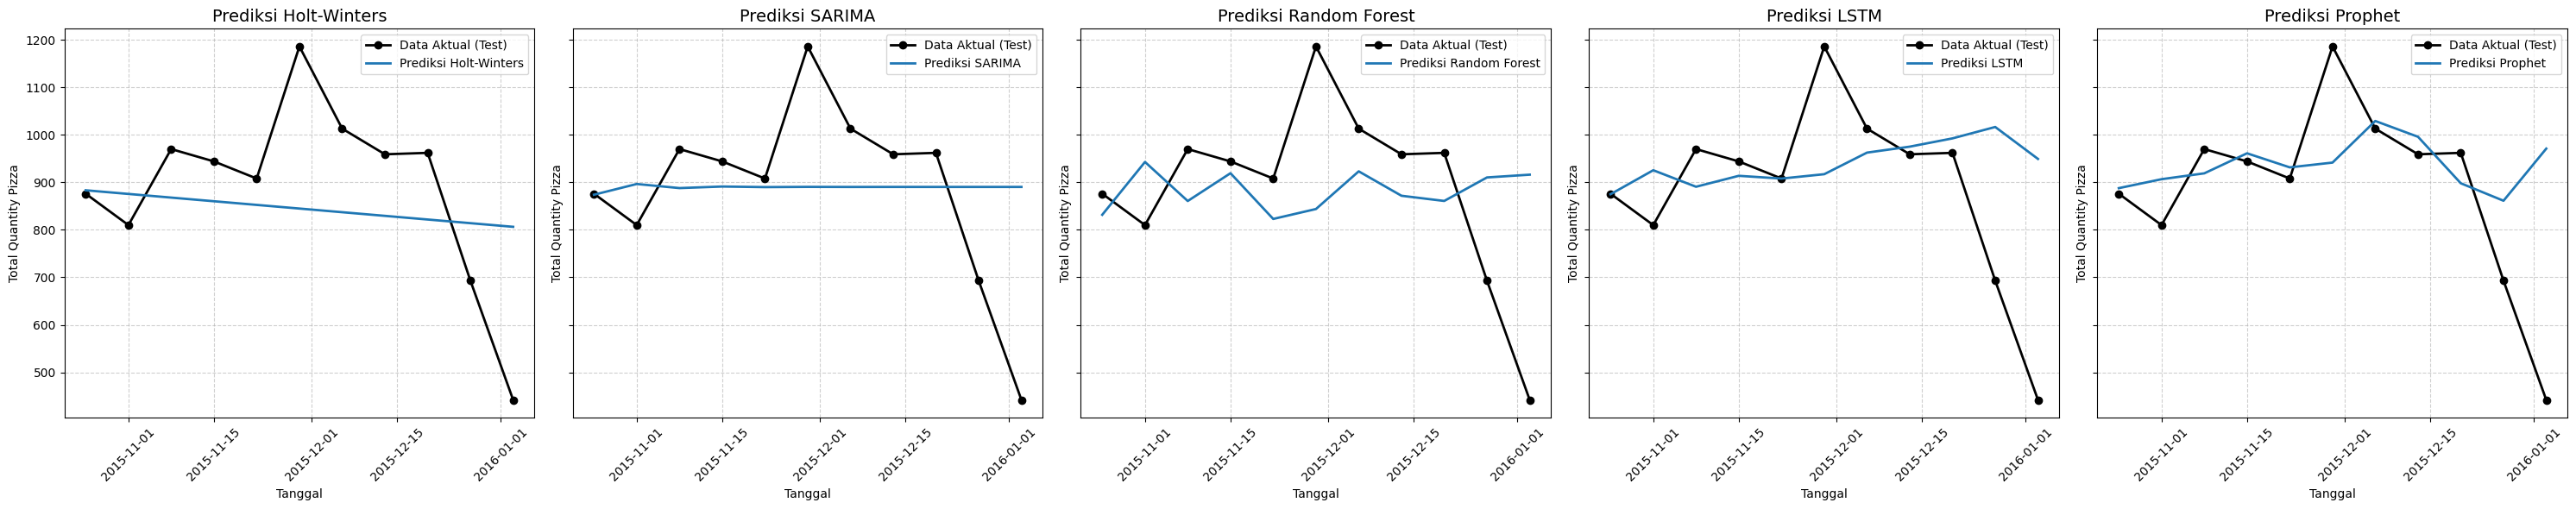

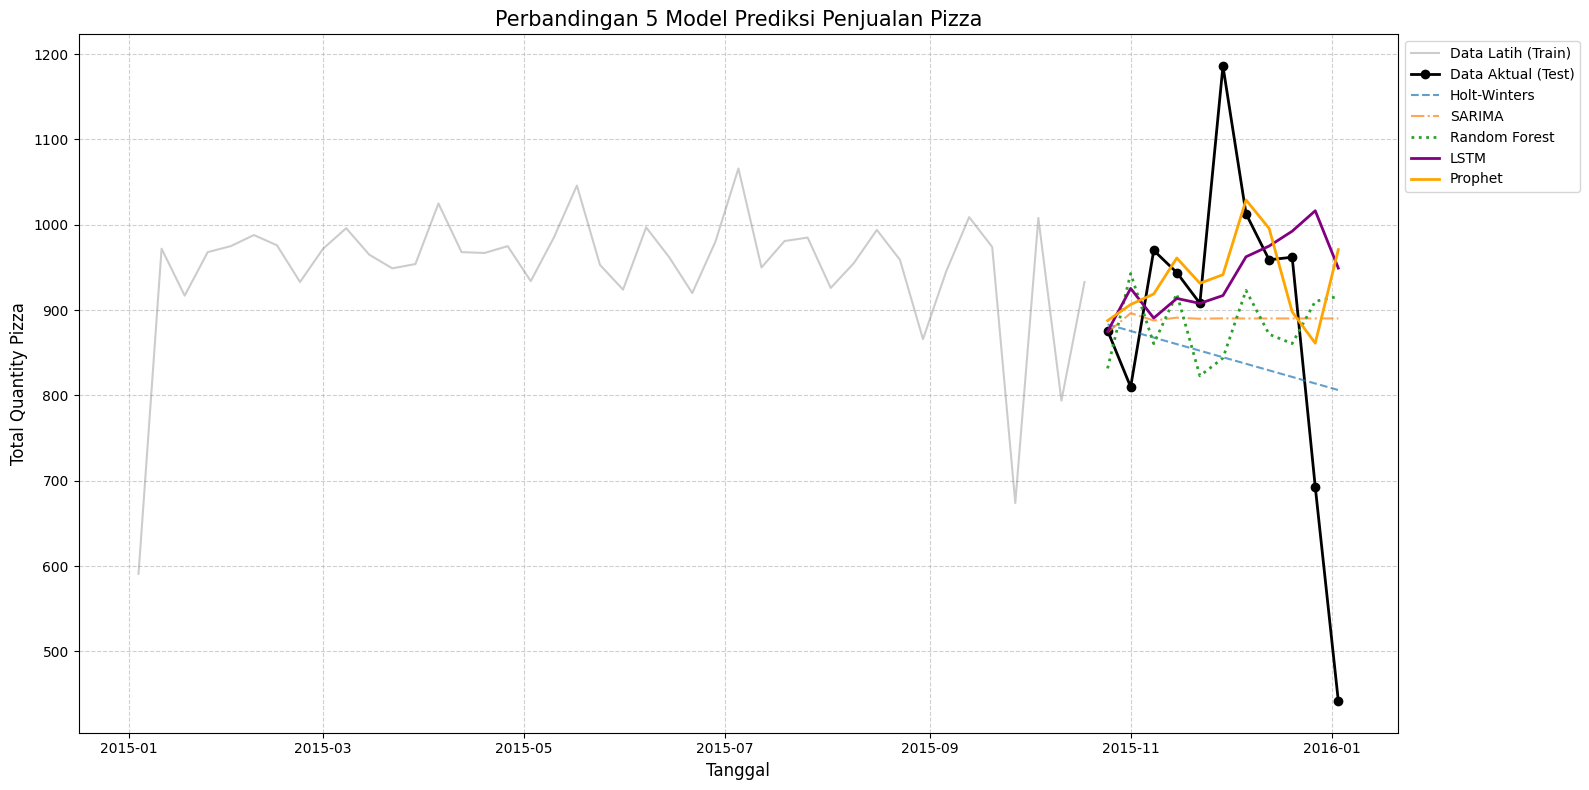


=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===


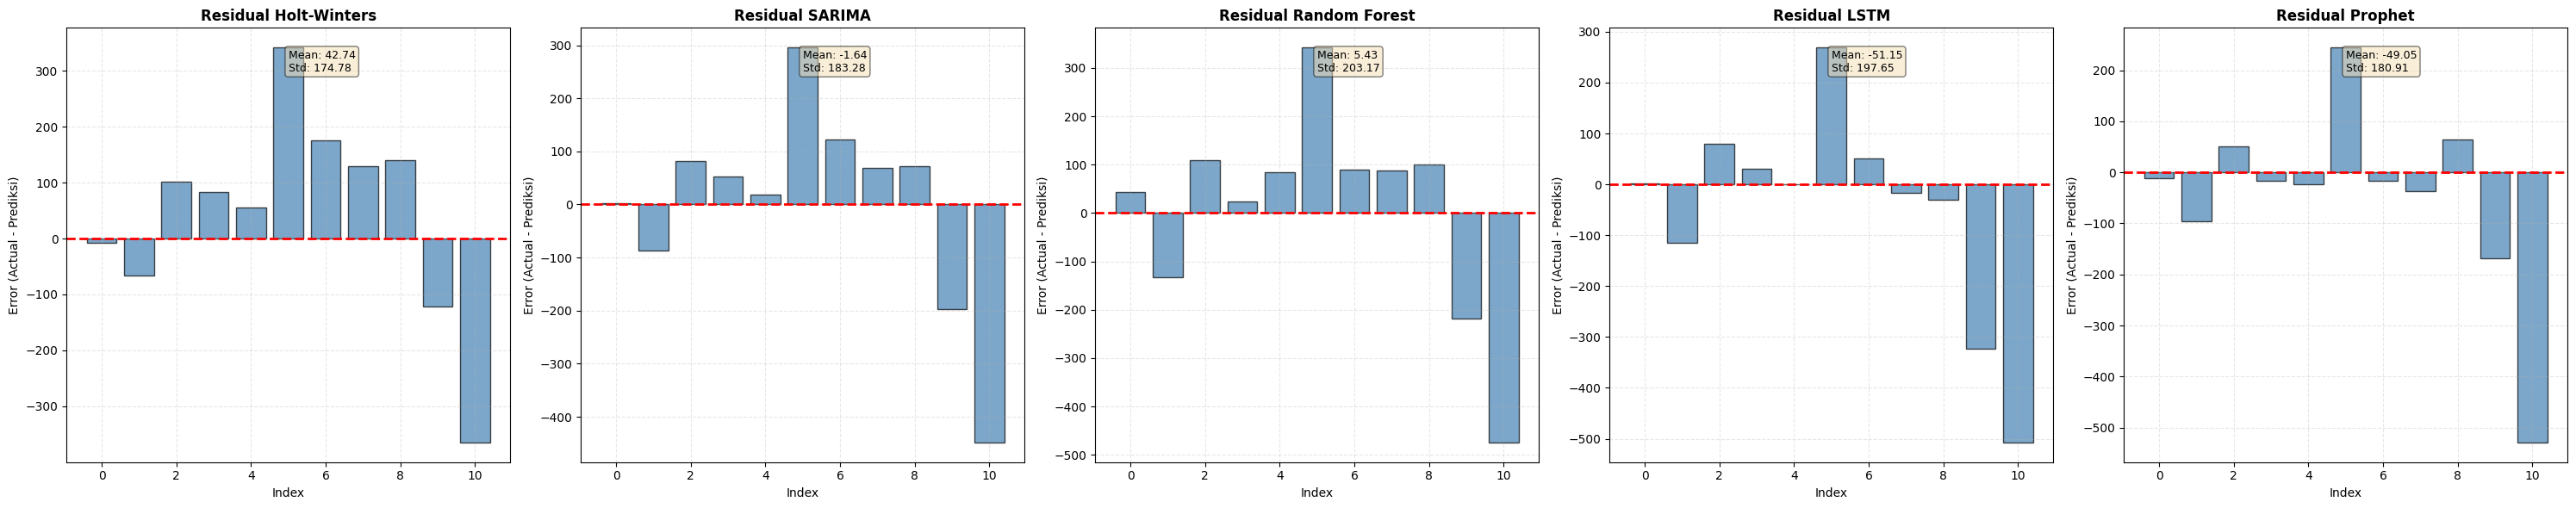


=== RANKING MODEL (SORTED BY SMAPE) ===
        Model  SMAPE (%)    MAE   RMSE    R²
      Prophet      14.01 114.41 187.44 -0.05
         LSTM      15.59 129.35 204.16 -0.24
       SARIMA      15.98 131.45 183.28 -0.00
 Holt-Winters      17.51 144.24 179.93  0.03
Random Forest      18.67 155.29 203.25 -0.23


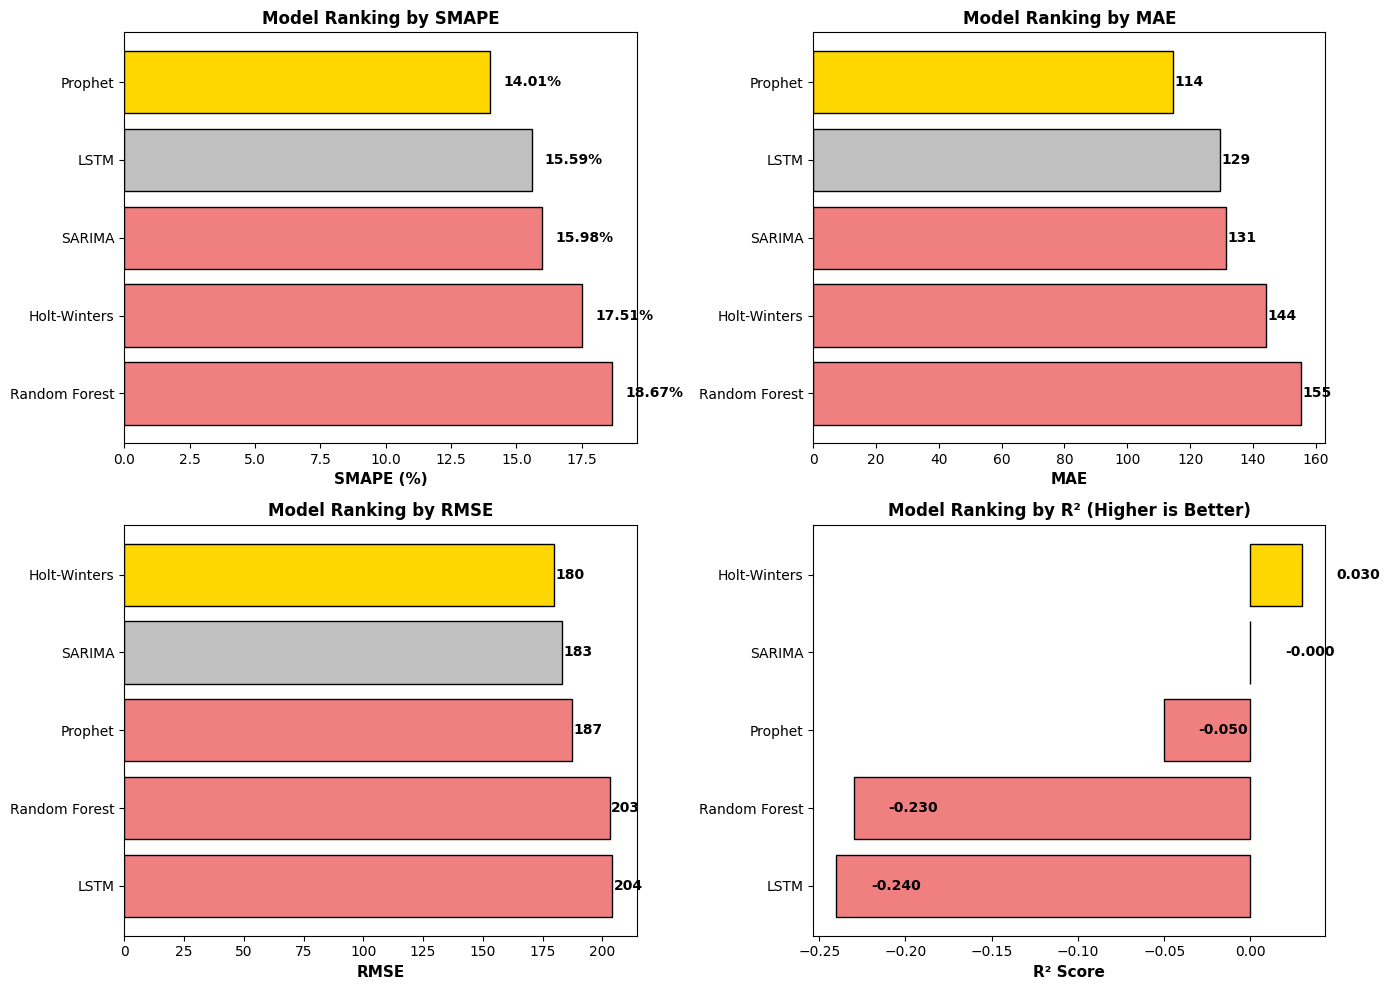

In [22]:
# ==========================================
# 6. GRAFIK PERBANDINGAN PREDIKSI (TERPISAH PER MODEL)
# ==========================================
models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharey=True)

for idx, model in enumerate(models_to_plot):
    axes[idx].plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)
    axes[idx].plot(test.index, predictions[model], label=f'Prediksi {model}', linestyle='-', linewidth=2)
    axes[idx].set_title(f'Prediksi {model}', fontsize=14)
    axes[idx].set_xlabel('Tanggal', fontsize=10)
    axes[idx].set_ylabel('Total Quantity Pizza', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.6)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Data Latih (Train)', color='grey', alpha=0.4)
plt.plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)

plt.plot(test.index, predictions['Holt-Winters'], label='Holt-Winters', linestyle='--', alpha=0.7)
plt.plot(test.index, predictions['SARIMA'], label='SARIMA', linestyle='-.', alpha=0.7)
plt.plot(test.index, predictions['Random Forest'], label='Random Forest', linestyle=':', linewidth=2)
plt.plot(test.index, predictions['LSTM'], label='LSTM', color='purple', linestyle='-', linewidth=2)
plt.plot(test.index, predictions['Prophet'], label='Prophet', color='orange', linestyle='-', linewidth=2)

plt.title('Perbandingan 5 Model Prediksi Penjualan Pizza', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Quantity Pizza', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 6B. GRAFIK PERBANDINGAN RESIDUAL ERROR
# ==========================================
print("\n=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===")
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
for idx, model in enumerate(models_to_plot):
    residuals = test.values - predictions[model].values
    axes[idx].bar(range(len(residuals)), residuals, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'Residual {model}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Index', fontsize=10)
    axes[idx].set_ylabel('Error (Actual - Prediksi)', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    # Tambahkan statistik
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    axes[idx].text(0.5, 0.95, f'Mean: {mean_residual:.2f}\nStd: {std_residual:.2f}', 
                   transform=axes[idx].transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 6C. RANKING MODEL BERDASARKAN METRIK
# ==========================================
print("\n=== RANKING MODEL (SORTED BY SMAPE) ===")
ranking = df_metrics[['Model', 'SMAPE (%)', 'MAE', 'RMSE', 'R²']].sort_values('SMAPE (%)')
print(ranking.to_string(index=False))

# Visualisasi ranking
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SMAPE Ranking
ax1 = axes[0, 0]
smape_sorted = df_metrics.sort_values('SMAPE (%)')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(smape_sorted))]
ax1.barh(range(len(smape_sorted)), smape_sorted['SMAPE (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(smape_sorted)))
ax1.set_yticklabels(smape_sorted['Model'])
ax1.set_xlabel('SMAPE (%)', fontsize=11, fontweight='bold')
ax1.set_title('Model Ranking by SMAPE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(smape_sorted['SMAPE (%)']):
    ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# MAE Ranking
ax2 = axes[0, 1]
mae_sorted = df_metrics.sort_values('MAE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(mae_sorted))]
ax2.barh(range(len(mae_sorted)), mae_sorted['MAE'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(mae_sorted)))
ax2.set_yticklabels(mae_sorted['Model'])
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Model Ranking by MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(mae_sorted['MAE']):
    ax2.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# RMSE Ranking
ax3 = axes[1, 0]
rmse_sorted = df_metrics.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(rmse_sorted))]
ax3.barh(range(len(rmse_sorted)), rmse_sorted['RMSE'], color=colors, edgecolor='black')
ax3.set_yticks(range(len(rmse_sorted)))
ax3.set_yticklabels(rmse_sorted['Model'])
ax3.set_xlabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Model Ranking by RMSE', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(rmse_sorted['RMSE']):
    ax3.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# R² Ranking
ax4 = axes[1, 1]
r2_sorted = df_metrics.sort_values('R²', ascending=False)
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(r2_sorted))]
ax4.barh(range(len(r2_sorted)), r2_sorted['R²'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(r2_sorted)))
ax4.set_yticklabels(r2_sorted['Model'])
ax4.set_xlabel('R² Score', fontsize=11, fontweight='bold')
ax4.set_title('Model Ranking by R² (Higher is Better)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(r2_sorted['R²']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


=== CONFUSION MATRIX TREN PENJUALAN ===


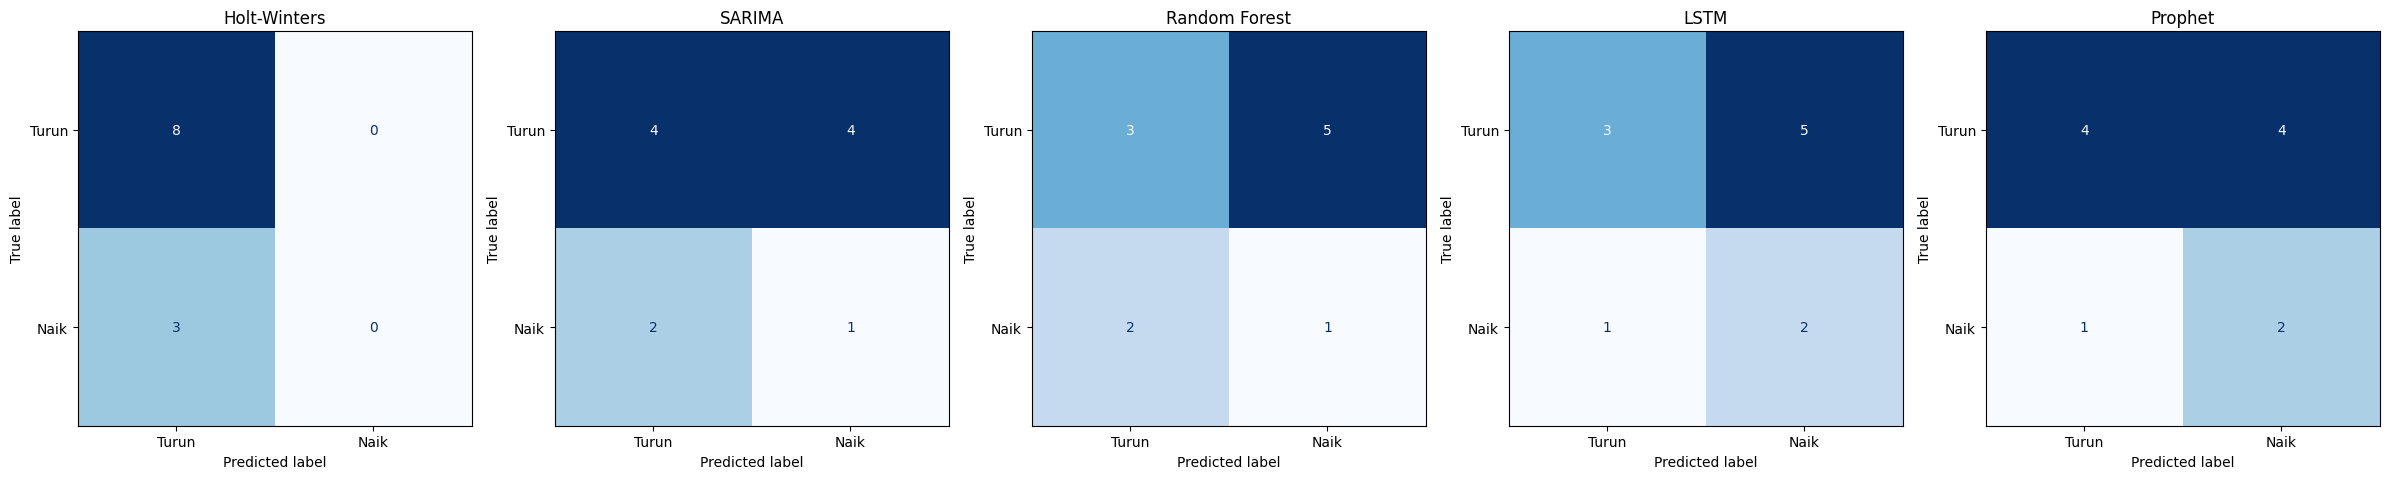

In [23]:
# ==========================================
# 7. CONFUSION MATRIX (KLASIFIKASI TREN NAIK/TURUN)
# ==========================================
print("\n=== CONFUSION MATRIX TREN PENJUALAN ===")

last_train_val = train.iloc[-1]
actual_shifted = np.append([last_train_val], test.values[:-1])
actual_trend = (test.values > actual_shifted).astype(int)

models_to_plot = ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for idx, model in enumerate(models_to_plot):
    pred_shifted = np.append([last_train_val], predictions[model].values[:-1])
    pred_trend = (predictions[model].values > pred_shifted).astype(int)

    cm = confusion_matrix(actual_trend, pred_trend, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Turun', 'Naik'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{model}')

plt.tight_layout()
plt.show()